# 1. Выбор датасета
## Датасет - Smartphone usage and addiction analysis.
Колонки:
- transaction_id: ID испытания
- user_id: ID испытуемого
- age: возраст испытуемого
- gender: гендер испытуемого
- daily_screen_time_hours: ежедневное экранное время
- social_media_hours: время, проводимое в социальных сетях ежедневно
- gaming_hours: ежедневное игровое время
- work_study_hours: время, проводимое в телефоне для работы или обучения ежедневно
- sleep_hours: среднее время сна
- notifications_per_day: количество уведомлений, полученных за день
- app_opens_per_day: сколько раз за день были открыты различные приложения
- weekend_screen_time: экранное время за выходные
- stress_level: уровень стресса
- academic_work_impact: влияние на обучение
- addiction_level: уровень зависимости
- addicted_label: есть ли зависимость

# 2. Первичный анализ данных

In [343]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.base import BaseEstimator
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

df = pandas.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [344]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   str    
 1   user_id                  7500 non-null   str    
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   str    
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   str    
 13  academic_work_impact     7500 non-null   str    
 14  addiction_level          6681 non-n

In [345]:
print("Кол-во записей:\n", df.count())
print("\nСтатистика:\n", df.describe(include="all"))
print("\nКол-во пропусков данных:\n", df.isnull().sum())

Кол-во записей:
 transaction_id             7500
user_id                    7500
age                        7500
gender                     7500
daily_screen_time_hours    7500
social_media_hours         7500
gaming_hours               7500
work_study_hours           7500
sleep_hours                7500
notifications_per_day      7500
app_opens_per_day          7500
weekend_screen_time        7500
stress_level               7500
academic_work_impact       7500
addiction_level            6681
addicted_label             7500
dtype: int64

Статистика:
        transaction_id user_id          age gender  daily_screen_time_hours  \
count            7500    7500  7500.000000   7500              7500.000000   
unique           7500    7500          NaN      3                      NaN   
top          TXN00001  U00001          NaN   Male                      NaN   
freq                1       1          NaN   2553                      NaN   
mean              NaN     NaN    26.568800    NaN     

# 3. Подготовка данных

Как видно выше, в колонках transaction_id и user_id по 7500 уникальных значений. Значит возьмем одну из колонок в качестве id, а другую удалим.

In [346]:
df.set_index("transaction_id", inplace=True)
df = df.drop(["user_id"], axis=1)
df.head()

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
transaction_id,,,,,,,,,,,,,,
TXN00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
TXN00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
TXN00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
TXN00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
TXN00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


Заметим, что у нас 819 пропсуков в колонке addiction_level. Если перейти в датасет и осуществить поиск по слову None, то мы увидим, что в датасете это слово встречается как раз 819 раз. То есть pandas воспринимает None как пропуск. Поэтому на самом деле пропусков в данных нет.

In [347]:
df[(df['addiction_level'].isnull())].shape

(819, 14)

Колонка addicted_label будет полностью линейно зависима от колонки addiction_level, так как в колонке addicted_label значение 0 только тогда, когда в колонке addiction_level значение None. Поэтому колонку addicted_label можно удалить.

In [ ]:
df = df.drop(["addicted_label"], axis=1)
df.head()

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level
transaction_id,,,,,,,,,,,,,
TXN00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN
TXN00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN
TXN00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild
TXN00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate
TXN00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe


К столбцам gender и academic_work_impact применим One Hot Encoding.

In [349]:
df = pandas.get_dummies(df, columns=["gender", "academic_work_impact"], drop_first=True)
df.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,addiction_level,gender_Male,gender_Other,academic_work_impact_Yes
transaction_id,,,,,,,,,,,,,,
TXN00001,21,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,NaN,True,False,True
TXN00002,24,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,NaN,False,True,True
TXN00003,31,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,Mild,False,True,False
TXN00004,32,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Moderate,False,True,True
TXN00005,25,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,Severe,True,False,False


Столбец stress_level закодируем с помощью Label Encoding, так как данные в этом столбце выражают степень стресса, т.е. данные являются порядковыми.

In [350]:
df['stress_level'].unique()

<StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str

In [351]:
oe = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
df['stress_level'] = oe.fit_transform(df[['stress_level']])
df.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,addiction_level,gender_Male,gender_Other,academic_work_impact_Yes
transaction_id,,,,,,,,,,,,,,
TXN00001,21,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1.0,NaN,True,False,True
TXN00002,24,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1.0,NaN,False,True,True
TXN00003,31,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2.0,Mild,False,True,False
TXN00004,32,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2.0,Moderate,False,True,True
TXN00005,25,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0.0,Severe,True,False,False


Проведем корреляционный анализ. Для этого переведем все интересующие колонки в числовые.

In [352]:
df1 = df.copy()
oe = OrdinalEncoder(categories=[[False, True]])
df1['gender_Male'] = oe.fit_transform(df1[['gender_Male']])
df1['gender_Other'] = oe.fit_transform(df1[['gender_Other']])
df1['academic_work_impact_Yes'] = oe.fit_transform(df1[['academic_work_impact_Yes']])

df1["addiction_level"] = df1["addiction_level"].fillna("zero")
oe = OrdinalEncoder(categories=[["zero", "Mild", "Moderate", "Severe"]])
df1['addiction_level'] = oe.fit_transform(df1[['addiction_level']])
df1.head()


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,addiction_level,gender_Male,gender_Other,academic_work_impact_Yes
transaction_id,,,,,,,,,,,,,,
TXN00001,21,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1.0,0.0,1.0,0.0,1.0
TXN00002,24,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1.0,0.0,0.0,1.0,1.0
TXN00003,31,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2.0,1.0,0.0,1.0,0.0
TXN00004,32,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2.0,2.0,0.0,1.0,1.0
TXN00005,25,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0.0,3.0,1.0,0.0,0.0


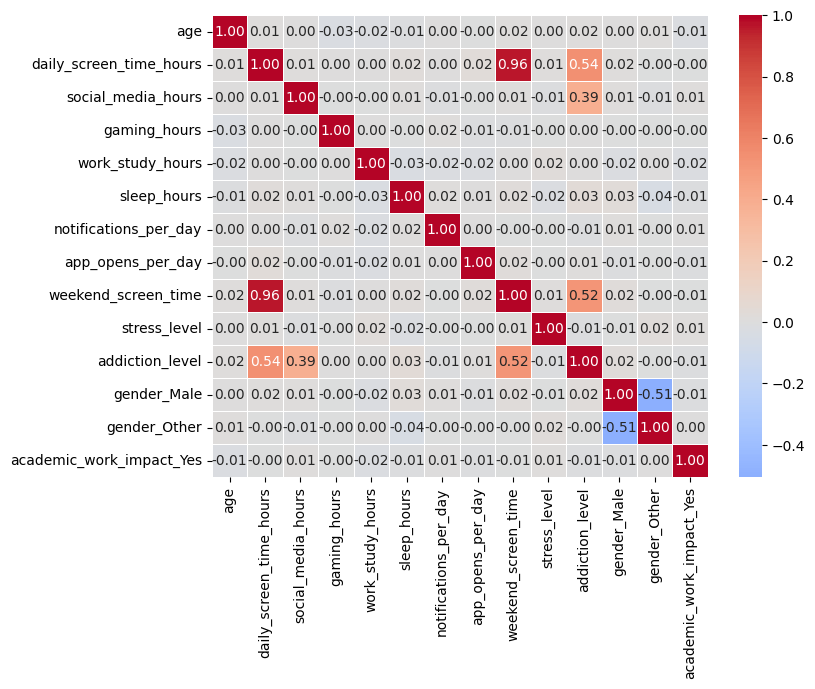

In [353]:

corr_matrix = df1.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, 
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.show()

<Axes: xlabel='addiction_level', ylabel='weekend_screen_time'>

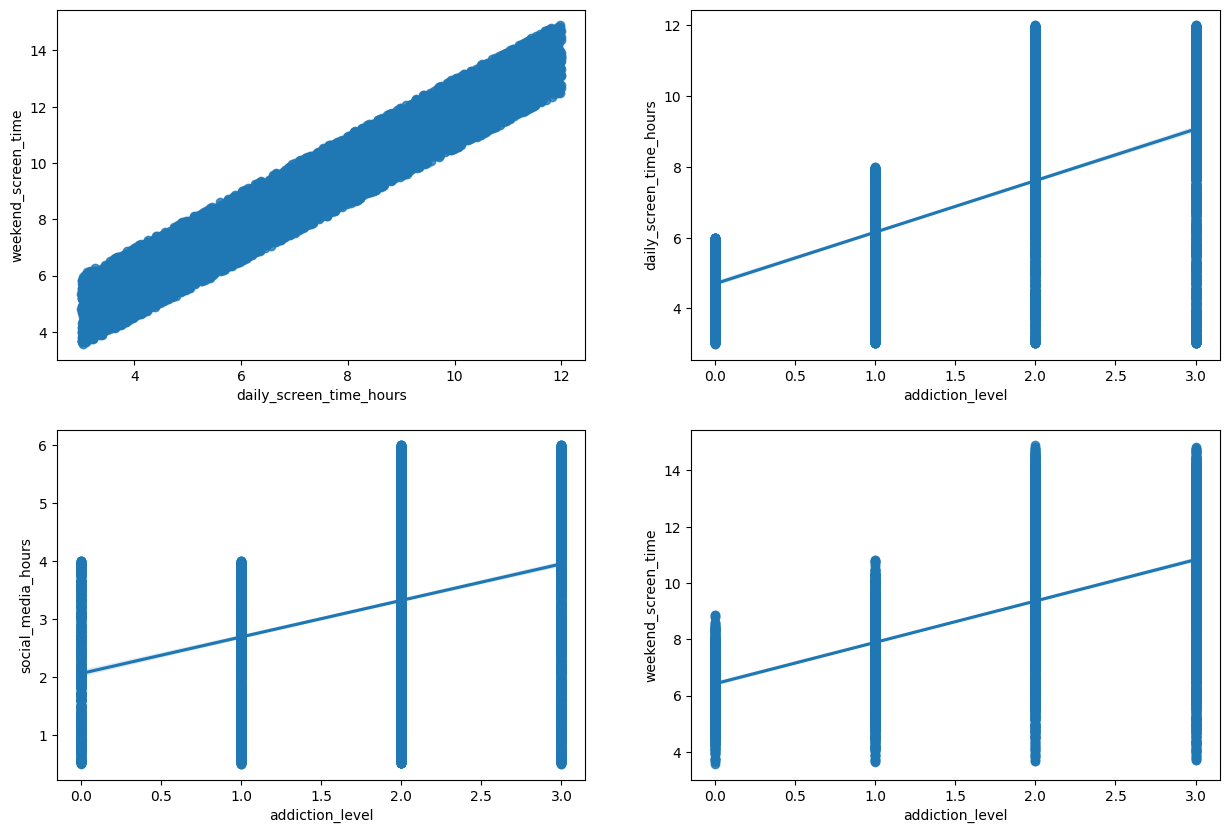

In [354]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

sns.regplot(x='daily_screen_time_hours', y='weekend_screen_time', data=df1, ax=axes[0])
sns.regplot(x='addiction_level', y='daily_screen_time_hours', data=df1, ax=axes[1])
sns.regplot(x='addiction_level', y='social_media_hours', data=df1, ax=axes[2])
sns.regplot(x='addiction_level', y='weekend_screen_time', data=df1, ax=axes[3])

<Axes: xlabel='daily_screen_time_hours', ylabel='weekend_screen_time'>

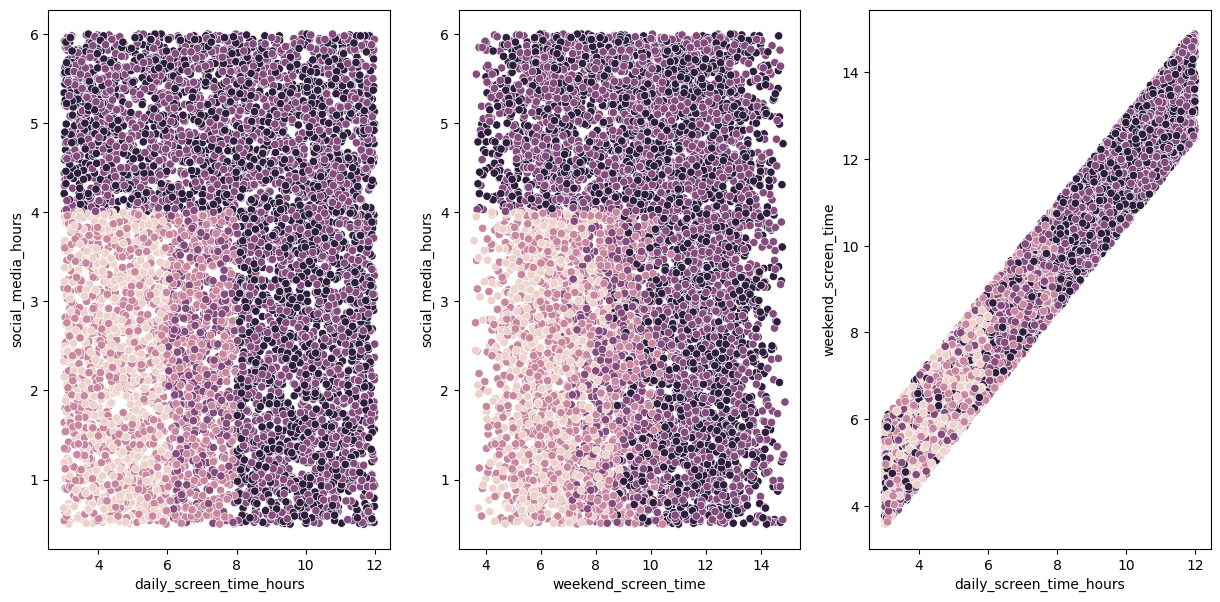

In [377]:
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
axes = axes.flatten()

sns.scatterplot(x='daily_screen_time_hours', y='social_media_hours', data=df1, hue="addiction_level", legend=False, ax=axes[0])
sns.scatterplot(x='weekend_screen_time', y='social_media_hours', data=df1, hue="addiction_level", legend=False, ax=axes[1])
sns.scatterplot(x='daily_screen_time_hours', y='weekend_screen_time', data=df1, hue="addiction_level", legend=False, ax=axes[2])

Можем заметить, что признаки weekend_screen_time и daily_screen_time_hours сильно скоррелированы. Поэтому удаляем признак weekend_screen_time.

In [356]:
df = df.drop(["weekend_screen_time"], axis=1)
df.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,stress_level,addiction_level,gender_Male,gender_Other,academic_work_impact_Yes
transaction_id,,,,,,,,,,,,,
TXN00001,21,3.23,2.01,0.89,4.55,7.55,248,154,1.0,NaN,True,False,True
TXN00002,24,5.09,3.81,2.24,4.44,7.66,127,71,1.0,NaN,False,True,True
TXN00003,31,6.06,1.36,3.83,2.35,4.92,44,106,2.0,Mild,False,True,False
TXN00004,32,7.83,5.85,1.51,3.54,8.23,178,107,2.0,Moderate,False,True,True
TXN00005,25,9.96,5.92,3.42,5.27,6.21,136,177,0.0,Severe,True,False,False


Проверим данные на наличие аномальных выбросов.

In [357]:
num_df = df.select_dtypes(include=['number'])
statistics = pandas.DataFrame(columns=num_df.columns)
statistics.loc['skewness'] = num_df.skew()     # Асимметрия
statistics.loc['kurtosis'] = num_df.kurt()     # Эксцесс
statistics

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,stress_level
skewness,-0.020705,-0.011366,-0.010258,-0.017238,0.006309,0.018713,0.002711,-0.010007,-0.014051
kurtosis,-1.225628,-1.215695,-1.196404,-1.185269,-1.215591,-1.175448,-1.188781,-1.218359,-1.518617


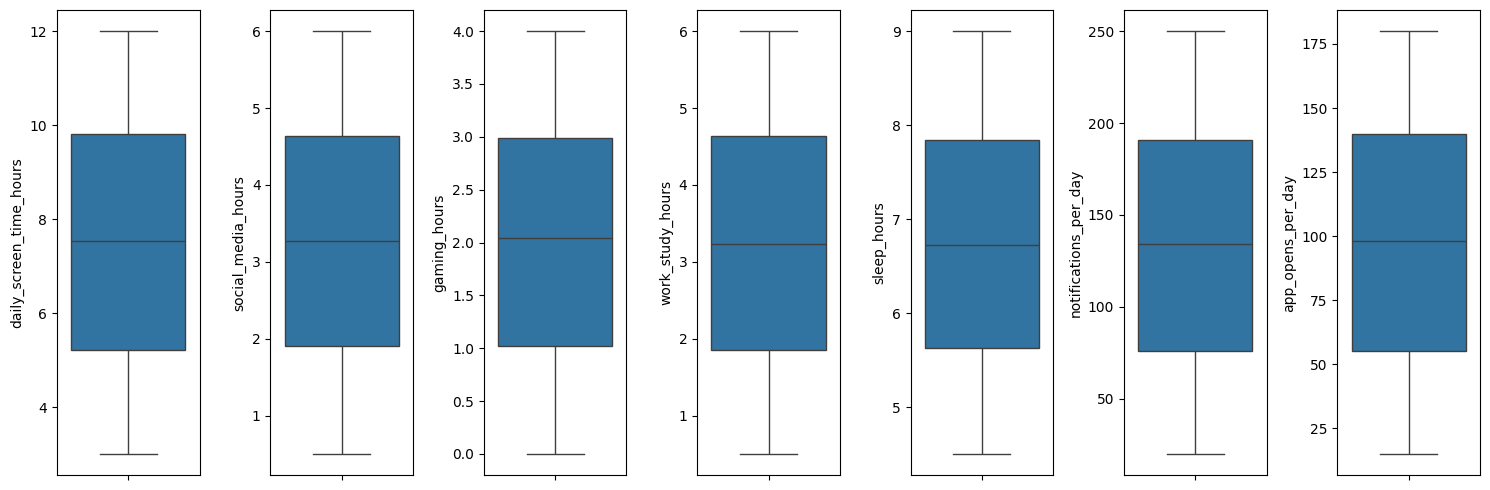

In [358]:
fig, axes = plt.subplots(1, 7, figsize=(15, 5))
axes = axes.flatten()

sns.boxplot(data=df, y='daily_screen_time_hours', ax=axes[0])
sns.boxplot(data=df, y='social_media_hours', ax=axes[1])
sns.boxplot(data=df, y='gaming_hours', ax=axes[2])
sns.boxplot(data=df, y='work_study_hours', ax=axes[3])
sns.boxplot(data=df, y='sleep_hours', ax=axes[4])
sns.boxplot(data=df, y='notifications_per_day', ax=axes[5])
sns.boxplot(data=df, y='app_opens_per_day', ax=axes[6])

plt.tight_layout()

По ассиметрии, эксцессу и графикам видно, что данные расположены равномерно и аномальных выбросов нет. Значит min-max scaler сработает хорошо.

C:\Users\User\AppData\Local\Temp\ipykernel_23460\1606071367.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['daily_screen_time_hours'], ax = axes[0])
C:\Users\User\AppData\Local\Temp\ipykernel_23460\1606071367.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['social_media_hours'], a

<Axes: xlabel='app_opens_per_day', ylabel='Density'>

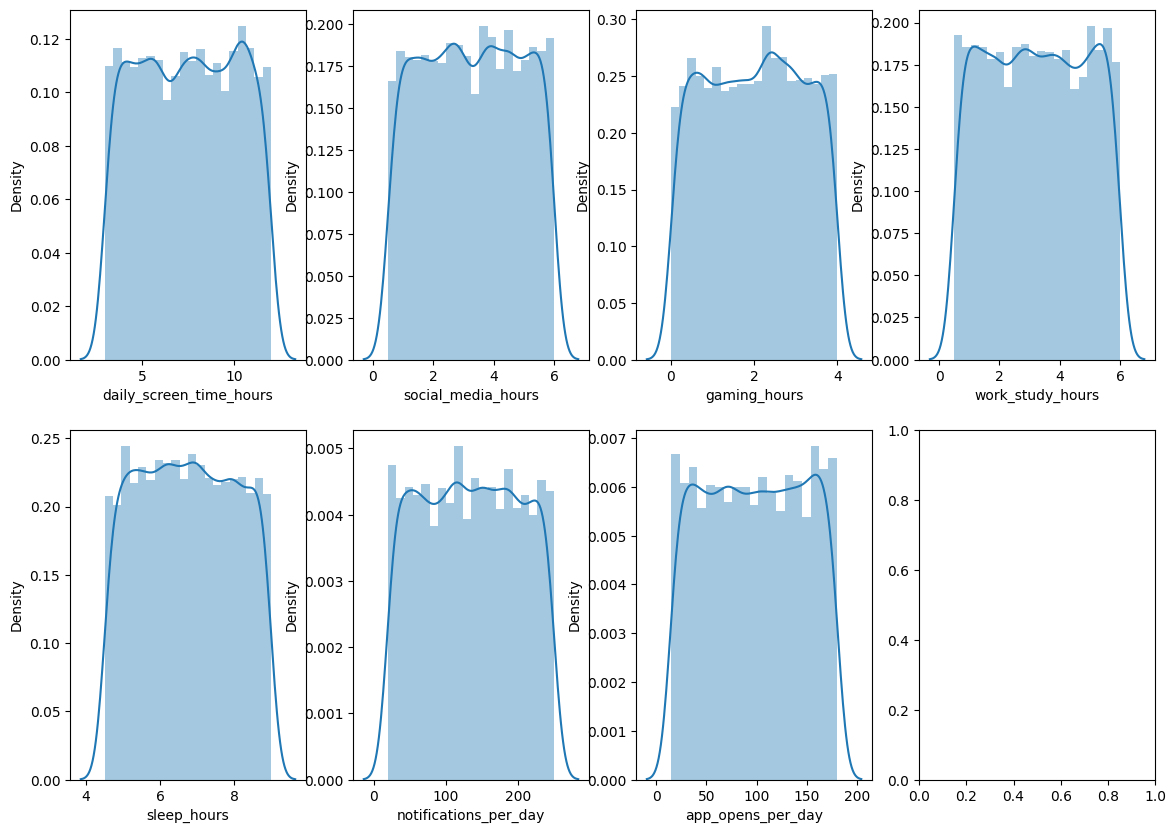

In [359]:
f, axes = plt.subplots(2,4,figsize=(14,10))
axes = axes.flatten()

sns.distplot(df['daily_screen_time_hours'], ax = axes[0])
sns.distplot(df['social_media_hours'], ax = axes[1])
sns.distplot(df['gaming_hours'], ax = axes[2])
sns.distplot(df['work_study_hours'], ax = axes[3])
sns.distplot(df['sleep_hours'], ax = axes[4])
sns.distplot(df['notifications_per_day'], ax = axes[5])
sns.distplot(df['app_opens_per_day'], ax = axes[6])

Разделим данные на параметры и категории.

In [360]:
X = df.copy().drop(["addiction_level"], axis=1)
y = df["addiction_level"].copy().fillna("Zero")

Далее разделим данные на train и test.

In [361]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42, stratify=y)

In [362]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [363]:
X_train

array([[0.94117647, 0.86444444, 0.82909091, ..., 0.        , 0.        ,
        0.        ],
       [0.52941176, 0.21222222, 0.64      , ..., 0.        , 1.        ,
        0.        ],
       [1.        , 0.11333333, 0.47818182, ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.23529412, 0.62888889, 0.29636364, ..., 0.        , 0.        ,
        0.        ],
       [0.35294118, 0.51777778, 0.58      , ..., 0.        , 1.        ,
        1.        ],
       [0.47058824, 0.83111111, 0.52      , ..., 0.        , 0.        ,
        1.        ]], shape=(6000, 12))

## Почему масштабирование важно для kNN?
Для kNN важно масштабирование, так как оно уравнивает важность признаков.

## Почему нельзя подбирать параметры на тестовой выборке?
Если подбирать параметр на тестовой выборке, то можно переобучить модель. Это происходит потому что параметр подгоняется под определенные данные. Поэтому на test выборке нельзя подбирать параметры. А чтобы не подбирать их "на глаз" на тренировочной выборке, можно разделить датасет на train, validation и test, что я и сделал выше. Тогда можно на validation выборке чуть точнее подобрать параметр, а на test выборке проверить работоспособность модели. Однако и этого может быть мало, тогда можно использовать кросс-валидацию и прочее.

In [364]:
# ds = pandas.read_csv("Iris.csv")
# ds

In [365]:
# X = ds.copy().drop(["Species"], axis=1)
# y = ds["Species"].copy()
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42, stratify=y)

# 4. Обучение kNN.

In [366]:
class kNN(BaseEstimator):
    __metrics_list = ["euclidean", "manhattan", "minkowski", "cosine"]
    __weights_list = ["uniform", "distance"]

    def __init__(self, n_neighbors=3, metric="euclidean", weights="uniform", *, p=3):
        self.__label_encoder = LabelEncoder()
        self.__scaler = MinMaxScaler()

        self.__train_category_array = None
        self.__train_destination_array = None
        
        if n_neighbors > 0:
            self.__n_neighbors = n_neighbors
        else:
            raise Exception("The number of the nearest neighbours can't be less than 1.")
        
        if metric in self.__metrics_list:
            self.__metric = metric
        else:
            raise Exception("There's no such metric.")
        
        if weights in self.__weights_list:
            self.__weights = weights
        else:
            raise Exception("You can use only \"unform\" or \"distance\" as weights.")
        
        if p >= 1:
            self.__p = p
        else:
            raise Exception("The parameter of the Minkowski metric can't be less than 1.")
        
    @property
    def train_destination_array(self):
        return self.__train_destination_array
        
    @train_destination_array.setter
    def train_destination_array(self, train_destination_array):
        self.__train_destination_array = self.__scaler.fit_transform(train_destination_array)

    @property
    def train_category_array(self):
        return self.__train_category_array
        
    @train_category_array.setter
    def train_category_array(self, train_category_array):
        self.__train_category_array = self.__label_encoder.fit_transform(train_category_array)

# check the shape of the arrays!!!!!!!!!!

    @property
    def n_neighbors(self):
        return self.__n_neighbors
    
    @n_neighbors.setter
    def n_neighbors(self, n_neighbors):
        if n_neighbors > 0:
            self.__n_neighbors = n_neighbors
        else: 
            raise Exception("The numbers of the nearest neighbours can't be less than 1.")
        
    @property
    def metric(self):
        return self.__metric
        
    @metric.setter
    def metric(self, metric):
        if metric in self.__metrics_list:
            self.__metric = metric
        else:
            raise Exception("There's no such metric.")
    
    @property
    def weights(self):
        return self.__weights
        
    @weights.setter
    def weights(self, weights):
        if weights in self.__weights_list:
            self.__weights = weights
        else:
            raise Exception("You can use only \"unform\" or \"distance\" as weights.")
        
    @property
    def p(self):
        return self.__p
        
    @p.setter
    def p(self, p):
        if p >= 1:
            self.__p = p
        else:
            raise Exception("The parameter of the Minkowski metric can't be less than 1.")
        
    def destination(self, target_array):
        target_array = np.asarray(target_array)
        if self.__metric == "euclidean":
            return np.sqrt(np.sum((target_array[:, np.newaxis, :] - self.__train_destination_array[np.newaxis, :, :]) ** 2, axis = 2))
        elif self.__metric == "manhattan":
            return np.sum(np.abs((target_array[:, np.newaxis, :] - self.__train_destination_array[np.newaxis, :, :])), axis=2)
        elif self.__metric == "minkowski":
            return np.sum(np.abs(target_array[:, np.newaxis, :] - self.__train_destination_array[np.newaxis, :, :]) ** self.__p, axis = 2) ** (1/self.__p)
        elif self.__metric == "cosine":
            return 1 - ((target_array @ self.__train_destination_array.T) / ((np.sqrt(np.sum(target_array**2, axis=1) + 1e-10))[:, np.newaxis] * (np.sqrt(np.sum(self.__train_destination_array**2, axis=1) + 1e-10))[np.newaxis, :]))
        else:
            raise ValueError("Unknown metric")
        
    def fit(self, train_destination_array, train_category_array):
        self.__train_destination_array = np.asarray(self.__scaler.fit_transform(train_destination_array))

        self.__train_category_array = np.asarray(self.__label_encoder.fit_transform(train_category_array))
        return self
        
    def predict(self, target_array):
        target_array = np.asarray(self.__scaler.transform(target_array))
        if self.__weights=="uniform":
            D = self.destination(target_array)
            idx = np.argsort(D)
            y_nearest = np.take_along_axis(self.__train_category_array[np.newaxis, :], idx)
            if self.__n_neighbors < y_nearest.shape[1]:
                y_nearest = y_nearest[:, :self.__n_neighbors]
            return self.__label_encoder.inverse_transform(np.apply_along_axis(lambda row: np.bincount(row).argmax(), axis=1, arr=y_nearest))
        elif self.__weights=="distance":
            D = self.destination(target_array)
            idx = np.argsort(D)
            y_nearest = np.take_along_axis(self.__train_category_array[np.newaxis, :], idx)
            D = np.take_along_axis(D, idx, axis=1)
            D = 1 / (D + 1e-10)
            if self.__n_neighbors < y_nearest.shape[1]:
                y_nearest = y_nearest[:, :self.__n_neighbors]
                D = D[:, :self.__n_neighbors]
            y_pred = np.empty(D.shape[0], dtype=int)
            for i in range(0, D.shape[0]):
                res = pandas.DataFrame({'key': y_nearest[i], 'val': D[i]}).groupby('key')['val'].sum().to_dict()
                y_pred[i] = max(res, key=res.get)
            return self.__label_encoder.inverse_transform(y_pred)


In [367]:
knn = kNN(n_neighbors=8,  metric = "manhattan", weights="distance", p=3)
knn.fit(X_train, y_train)
R = knn.predict(X_test)

slknn = KNeighborsClassifier(n_neighbors=8,  metric = "manhattan", weights="distance", p=3)
slknn.fit(X_train, y_train)
slR = slknn.predict(X_test)

In [368]:
print("accuracy of my kNN: ", metrics.accuracy_score(y_test, R))
print("accuracy of scikit learn kNN: ", metrics.accuracy_score(y_test, slR))

accuracy of my kNN:  0.446
accuracy of scikit learn kNN:  0.446


In [369]:
print("f1 of my kNN: ", metrics.f1_score(R, y_test, average=None))
print("f1 of scikit learn kNN: ", metrics.f1_score(slR, y_test, average=None))

f1 of my kNN:  [0.47407407 0.48784441 0.40598291 0.34482759]
f1 of scikit learn kNN:  [0.47407407 0.48784441 0.40598291 0.34482759]


In [370]:
print("params of my kNN: ", knn.get_params())
print("params of scikit learn kNN: ", slknn.get_params())

params of my kNN:  {'metric': 'manhattan', 'n_neighbors': 8, 'p': 3, 'weights': 'distance'}
params of scikit learn kNN:  {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'manhattan', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 8, 'p': 3, 'weights': 'distance'}


In [371]:
params = [{
    'metric': ['euclidean', 'manhattan', 'cosine'],
    'n_neighbors': list(range(1, 50)),
    'weights': ['uniform', 'distance']
},
{
    'metric': ['minkowski'],
    'n_neighbors': list(range(1, 50)),
    'p': list(range(3, 15)),
    'weights': ['uniform', 'distance']
}
]

gs = GridSearchCV(kNN(), params, scoring='f1_macro', cv=5, n_jobs=10)
gs.fit(X_train, y_train)
slgs = GridSearchCV(KNeighborsClassifier(), params, scoring='f1_macro', cv=5, n_jobs=10)
slgs.fit(X_train, y_train)

d:\coding\side_projects\ML_course\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan 0.36927637 ...        nan        nan        nan]
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [1, 2, ...], 'weights': ['uniform', 'distance']}, {'metric': ['minkowski'], 'n_neighbors': [1, 2, ...], 'p': [3, 4, ...], 'weights': ['uniform', 'distance']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the ver

In [373]:
results = pandas.DataFrame(gs.cv_results_)
slresults = pandas.DataFrame(slgs.cv_results_)
knn = gs.best_estimator_
slknn = slgs.best_estimator_

R = knn.predict(X_test)
slR = slknn.predict(X_test)

In [374]:
print("accuracy of my kNN: ", metrics.accuracy_score(y_test, R))
print("accuracy of scikit learn kNN: ", metrics.accuracy_score(y_test, slR))

accuracy of my kNN:  0.446
accuracy of scikit learn kNN:  0.446


In [376]:
print("f1 of my kNN: ", metrics.f1_score(R, y_test, average=None))
print("f1 of scikit learn kNN: ", metrics.f1_score(slR, y_test, average=None))

f1 of my kNN:  [0.47407407 0.48784441 0.40598291 0.34482759]
f1 of scikit learn kNN:  [0.47407407 0.48784441 0.40598291 0.34482759]


In [375]:
minkowski_param_results = results[(results['param_metric'] == 'euclidean') & (results['param_weights'] == 'uniform')]
minkowski_param_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_metric,param_n_neighbors,param_weights,param_p,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003663,0.001085,1.242540,0.455833,euclidean,1,uniform,NaN,"{'metric': 'euclidean', 'n_neighbors': 1, 'wei...",0.411010,NaN,NaN,NaN,0.403916,NaN,NaN,294
2,0.004794,0.000403,1.526762,0.010468,euclidean,2,uniform,NaN,"{'metric': 'euclidean', 'n_neighbors': 2, 'wei...",0.365171,0.372156,0.359384,0.376221,0.373451,0.369276,0.006143,273
4,0.003417,0.000919,1.144719,0.375061,euclidean,3,uniform,NaN,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.397483,0.403735,0.399172,NaN,0.424980,NaN,NaN,294
6,0.003479,0.001173,1.071918,0.046909,euclidean,4,uniform,NaN,"{'metric': 'euclidean', 'n_neighbors': 4, 'wei...",0.397712,0.394480,0.393084,0.420911,0.422409,0.405719,0.013111,190
8,0.003109,0.000750,1.141836,0.026641,euclidean,5,uniform,NaN,"{'metric': 'euclidean', 'n_neighbors': 5, 'wei...",0.394732,0.395050,0.416182,0.418781,0.429124,0.410774,0.013672,158


5.

In [164]:
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_metric,param_n_neighbours,param_weights,param_p,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000644,0.000107,0.604974,0.008467,euclidean,1,uniform,NaN,"{'metric': 'euclidean', 'n_neighbours': 1, 'we...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,131
1,0.000611,0.000103,0.522640,0.196222,euclidean,1,distance,NaN,"{'metric': 'euclidean', 'n_neighbours': 1, 'we...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,131
2,0.000804,0.000483,0.007696,0.004367,euclidean,2,uniform,NaN,"{'metric': 'euclidean', 'n_neighbours': 2, 'we...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,131
3,0.000513,0.000112,0.002709,0.001125,euclidean,2,distance,NaN,"{'metric': 'euclidean', 'n_neighbours': 2, 'we...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,131
4,0.000538,0.000014,0.002481,0.000185,euclidean,3,uniform,NaN,"{'metric': 'euclidean', 'n_neighbours': 3, 'we...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,0.000411,0.000122,0.001832,0.000154,minkowski,49,distance,12.0,"{'metric': 'minkowski', 'n_neighbours': 49, 'p...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,131
1466,0.000501,0.000013,0.002035,0.000083,minkowski,49,uniform,13.0,"{'metric': 'minkowski', 'n_neighbours': 49, 'p...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,131
1467,0.000469,0.000063,0.002188,0.000189,minkowski,49,distance,13.0,"{'metric': 'minkowski', 'n_neighbours': 49, 'p...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,131
1468,0.000365,0.000069,0.001747,0.000250,minkowski,49,uniform,14.0,"{'metric': 'minkowski', 'n_neighbours': 49, 'p...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,131


In [ ]:
results[(results['param_metric'] == 'cosine') & (results['param_weights'] == 'uniform') & (results['param_n_neighbours'] == 20)]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_metric,param_n_neighbours,param_weights,param_p,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
234,0.000635,0.000137,0.002947,0.000756,cosine,20,uniform,NaN,"{'metric': 'cosine', 'n_neighbours': 20, 'weig...",1.0,1.0,1.0,0.940741,0.940741,0.976296,0.029031,1
